![image.png](https://i.imgur.com/a3uAqnb.png)


#  Asthma Detection with WaveNet — Homework Assignment

**Objective**: Build a full pipeline that trains a **WaveNet classifier** (using raw audio) on lung sounds to detect respiratory conditions such as asthma, COPD, etc.

**WaveNet** is an advanced architecture specially designed for audio. It leverages **dilated causal 1D convolutions**, **gated activations**, and **residual plus skip connections** to efficiently capture long-range temporal dependencies **without exploding compute or parameter growth**. The dilation exponentially expands the receptive field, enabling the network to incorporate broader context using a modest number of layers. This design outperforms standard 1D CNNs in modeling long-range audio structures while maintaining training efficiency and stable convergence through residual learning.


## Download the dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammedtawfikmusaed/asthma-detection-dataset-version-2")

print("Path to dataset files:", path)

In [10]:
# =========================================================
# Imports & global config
# =========================================================
import os, math, random, time
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Repro
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Paths / classes
DATA_DIR = # To Do
CLASS_NAMES = ["asthma", "Bronchial", "copd", "healthy", "pneumonia"]
label2id = {c:i for i,c in enumerate(CLASS_NAMES)}
id2label = {i:c for c,i in label2id.items()}

# Audio params
TARGET_SR = 4000       # widely used for lung sounds
CLIP_SECONDS = 5.0     # dataset clips ~1.5–5s → fix to 5s
MAX_LEN = int(TARGET_SR * CLIP_SECONDS)

# Training
BATCH_SIZE = 64
EPOCHS = 35
LR = 2e-3
WD = 1e-4
NUM_FOLDS = 5
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = torch.cuda.is_available()


## [TODO] Build a DataFrame from folders

**Instructions:**  
- Traverse each class folder under `DATA_DIR` using `CLASS_NAMES`.  
- For every `.wav` file, record:
  - `path`: the string path to the file  
  - `label`: integer label via `label2id[class_name]`  
- Combine these records into a pandas DataFrame.  
- Shuffle the DataFrame using `random_state=SEED` for reproducibility.  
- Print out the label counts to verify distribution.


In [34]:
# =========================================================
# Build dataframe from directory structure
# =========================================================
def build_df(root: Path):
    # TODO: iterate over CLASS_NAMES; for each, glob *.wav and append dicts: {"path": str(wav), "label": label2id[cls]}
    # TODO: create DataFrame, shuffle with random_state=SEED, reset index
    # TODO: print value_counts of labels
    # return df

# TODO: df = build_df(DATA_DIR)
# TODO: print("Total files:", len(df))


label
0    288
1    104
2    401
3    133
4    285
Name: count, dtype: int64  (by label id)
Total files: 1211


### [TODO] Audio loader: resample, mono, normalize, pad/trim to 5s

**Instructions:**  
- Use `torchaudio.load(path)` to get `waveform [C, T]` and sample rate `sr`.  
- Convert to mono by averaging channels if `C > 1`.  
- If `sr != TARGET_SR`, resample with `torchaudio.functional.resample`.  
- Normalize amplitude by dividing by `max(abs(x)) + ε`.  
- Pad with zeros or trim so that the final tensor has length `MAX_LEN`.  
- Return a tensor of shape `[1, T]`.


In [12]:
# =========================================================
# Audio loading utils
# =========================================================
def load_wave_fixed(path: str):
    # TODO: wav, sr = torchaudio.load(path)
    # TODO: make mono if C>1 (mean over dim=0, keepdim=True)
    # TODO: resample if sr != TARGET_SR (torchaudio.functional.resample)
    # TODO: amplitude normalization
    # TODO: pad/crop to MAX_LEN
    # TODO: return waveform as shape [1, T]


### [TODO] Dataset & DataLoaders (+ class weights)

**Instructions:**  
1. Implement `LungSoundsDataset`:
   - Accept a DataFrame in the constructor and store it.
   - `__len__` returns number of rows.
   - `__getitem__(idx)` returns `(x, y)` where:
     - `x` is your preprocessed waveform `[1, T]`
     - `y` is the integer label.

2. Create `make_loaders(train_df, val_df)`:
   - Train loader: `shuffle=True`, `drop_last=True`.
   - Validation loader: `shuffle=False`.

3. Compute class weights:
   - `calculate counts`
   - `class_weights = total_sum / counts`
   - `class_weights = class_weights / class_weights.mean()` to scale ≈ 1.


In [13]:
# =========================================================
# Dataset & per-fold dataloaders
# =========================================================
class LungSoundsDataset(Dataset):
    def __init__(self, dframe: pd.DataFrame):
        # TODO: store a reset_index copy
        pass

    def __len__(self):
        # TODO: return dataset length
        pass

    def __getitem__(self, idx):
        # TODO: read row, load x with load_wave_fixed, cast y=int
        # TODO: return x (tensor [1, T]) and y (int)

def make_loaders(train_df, val_df):
    # TODO: create DataLoader for train (shuffle=True, drop_last=True) and val (shuffle=False)
    # TODO: return (train_loader, val_loader)

# TODO: calculate the classes weights
# TODO: class_weights = (class_weights / class_weights.mean()).to(DEVICE)
# TODO: print classes weights 


Class weights: [0.6524541  1.8067958  0.46859542 1.4128327  0.65932196]


### [TODO] Implement WaveNet

**Instructions:**  
You will implement a WaveNet-style classifier including:  
- **CausalConv1d**: causal convolution with left padding growing with dilation.  
- **WaveNetResidualBlock**: gated residual unit with filter conv, gate conv, dropout, and both residual + skip 1x1 convolutions.  
- **WaveNetClassifier**: 
  - Input projection via 1x1 conv.  
  - Stack multiple residual blocks with exponentially increasing dilations per stack.  
  - Sum skip connections from all blocks.  
  - Head: ReLU → 1x1 conv → ReLU → 1x1 conv to produce class logits.  
  - Apply global average pooling over the time dimension.  


In [29]:
# =========================================================
# WaveNet (causal dilated convs) for raw audio classification
# =========================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

class CausalConv1d(nn.Module):
    """1D causal conv implemented via left padding + no internal padding."""
    def __init__(self, in_ch, out_ch, kernel_size=2, dilation=1):
        super().__init__()
        # TODO: compute left pad = (kernel_size - 1) * dilation
        # TODO: define a Conv1d with padding=0 and given dilation

    def forward(self, x):
        # TODO: left-pad ONLY on the time axis using F.pad((pad, 0))
        # TODO: apply conv

class WaveNetResidualBlock(nn.Module):
    """
    Gated residual unit:
      z = tanh(Conv_dil(x)) * sigmoid(Conv_dil(x))
      residual = Conv1x1(z) + x
      skip     = Conv1x1(z)
    """
    def __init__(self, channels, skip_channels, kernel_size=2, dilation=1, dropout=0.05):
        super().__init__()
        # TODO: define two dilated causal convs. One for filter and one for gate
        # TODO: dropout layer
        # TODO: 1x1 conv for residual and 1x1 conv for skip

    def forward(self, x):
        # TODO: f = tanh(filter(x)); g = sigmoid(gate(x)); z = dropout(f * g)
        # TODO: res = res_conv(z); skip = skip_conv(z)
        # TODO: out = x + res   (residual connection)
        # TODO: return out, skip

class WaveNetClassifier(nn.Module):
    """
    Stacked dilated causal conv blocks with skip aggregation and global pooling.
    Suitable for clip-level classification on raw waveforms [B, 1, T].
    """
    def __init__(self, num_classes, in_channels=1, res_channels=64, skip_channels=128,
                 kernel_size=2, layers_per_stack=10, num_stacks=2, dropout=0.05):
        super().__init__()
        # TODO: input 1x1 conv to project in_channels -> res_channels
        # TODO: build stacks: for each stack, for l in [0..layers_per_stack-1], dilation=2**l, append WaveNetResidualBlock
        # TODO: store blocks in nn.ModuleList
        # TODO: define 'out' as: ReLU -> 1x1 conv (skip->skip) -> ReLU -> 1x1 conv (skip->num_classes)

    def forward(self, x):                      # x: [B, 1, T]
        # TODO: x = input_proj(x)
        # TODO: iterate over blocks: x, skip = block(x); accumulate skip_sum
        # TODO: y = out(ReLU(skip_sum)) -> [B, num_classes, T]
        # TODO: global average pool over time: y.mean(dim=-1)
        # TODO: return logits [B, num_classes]

model = WaveNetClassifier(num_classes=len(CLASS_NAMES)).to(DEVICE)
print(f"{sum(p.numel() for p in model.parameters())/1e6:.2f} M params")

0.60 M params


## Training and Validation loops

In [30]:
# =========================================================
# Optimizer, scheduler, loss; eval helpers
# =========================================================
def make_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_tgts = [], []
    losses = []
    criterion_eval = nn.CrossEntropyLoss()
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        loss = criterion_eval(logits, y)
        preds = logits.argmax(1)
        losses.append(loss.item())
        all_preds.append(preds.detach().cpu().numpy())
        all_tgts.append(y.detach().cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_tgts)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    return float(np.mean(losses)), acc, f1m, y_true, y_pred


### [TODO] K-fold training loop + early stopping + checkpointing

**Instructions:**  
- Initialize `StratifiedKFold(NUM_FOLDS, shuffle=True, random_state=SEED)`.  
- Loop over folds:
  - Split DataFrame into train/val.
  - Build DataLoaders, model (WaveNet), optimizer, scaler, and criterion using weighted loss.
  - Initialize lists `train_losses`, `val_losses` for tracking.
  - For each epoch:
    - Run `train_one_epoch(...)`, then `evaluate(...)`, append losses, compute metrics.
    - Print epoch metrics (losses, acc, macro-F1).
    - If the validation macro-F1 improves, save model checkpoint and reset patience.
    - If patience exceeds limit, break training loop early.
  - After fold completion, load the best model, evaluate, print classification report, and log fold metrics (accuracy, F1).


In [31]:
# =========================================================
# Train across folds (set RUN_SINGLE_FOLD to train one fold fast)
# =========================================================
RUN_SINGLE_FOLD = True
SINGLE_FOLD_IDX = 0

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df["path"], df["label"]))
selected_folds = [folds[SINGLE_FOLD_IDX]] if RUN_SINGLE_FOLD else folds

history = []

for fold_idx, (tr_idx, va_idx) in enumerate(selected_folds):
    print(f"\n========== Fold {fold_idx} ==========")
    # TODO: split df into tr_df / va_df
    # TODO: tr_loader, va_loader = make_loaders(...)
    # TODO: instantiate model = WaveNetClassifier(...)
    # TODO: optimizer = make_optimizer(model); scaler = torch.cuda.amp.GradScaler(enabled=AMP)
    # TODO: criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_f1 = -1.0
    patience, patience_limit = 0, 6
    ckpt_path = f"best_fold{fold_idx}.pt"

    # TODO: initialize lists to track losses for plotting
    # train_losses, val_losses = [], []

    for epoch in range(1, EPOCHS+1):
        t0 = time.time()
        # TODO: tr_loss = train_one_epoch(...)
        # TODO: va_loss, va_acc, va_f1, y_true, y_pred = evaluate(...)
        # TODO: append losses to tracking lists
        # TODO: print formatted log line with losses/metrics and elapsed time

        # TODO: checkpoint on best macro-F1; else increase patience and early stop
        # if va_f1 > best_f1: save; reset patience else patience += 1 and break if limit

    # TODO: load best checkpoint and run a final evaluate
    # TODO: print classification_report and append to history



========== Fold 0 ==========


/tmp/ipykernel_36/759874261.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP)


Epoch 01 | tr_loss 1.9931 | va_loss 1.6236 | acc 0.2346 | f1_macro 0.0760 | 7.0s
Epoch 02 | tr_loss 1.4575 | va_loss 1.7085 | acc 0.2346 | f1_macro 0.0954 | 6.8s
Epoch 03 | tr_loss 1.2854 | va_loss 1.4018 | acc 0.5062 | f1_macro 0.3939 | 6.7s
Epoch 04 | tr_loss 1.1249 | va_loss 1.3034 | acc 0.5391 | f1_macro 0.4968 | 6.8s
Epoch 05 | tr_loss 1.0921 | va_loss 1.4561 | acc 0.3704 | f1_macro 0.2796 | 7.1s
Epoch 06 | tr_loss 0.9929 | va_loss 1.2893 | acc 0.5885 | f1_macro 0.4875 | 7.1s
Epoch 07 | tr_loss 0.9098 | va_loss 1.1506 | acc 0.5926 | f1_macro 0.5523 | 6.8s
Epoch 08 | tr_loss 0.9131 | va_loss 0.9341 | acc 0.6996 | f1_macro 0.6758 | 6.8s
Epoch 09 | tr_loss 0.7812 | va_loss 0.9177 | acc 0.6502 | f1_macro 0.6193 | 6.8s
Epoch 10 | tr_loss 0.6960 | va_loss 1.0616 | acc 0.7325 | f1_macro 0.7022 | 6.7s
Epoch 11 | tr_loss 0.6804 | va_loss 1.0881 | acc 0.6337 | f1_macro 0.6143 | 6.5s
Epoch 12 | tr_loss 0.6603 | va_loss 1.3038 | acc 0.5926 | f1_macro 0.5560 | 7.0s
Epoch 13 | tr_loss 0.6097 | 

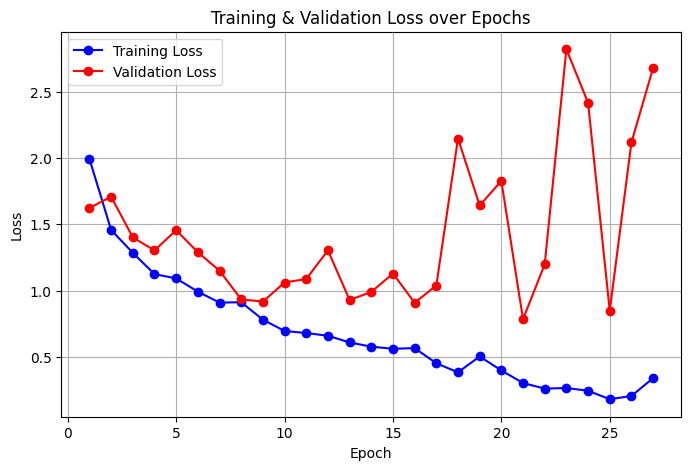

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs, val_losses,   'r-o', label='Validation Loss')
plt.title('Training & Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


##  Evaluation Criteria

Your **Audio Classification** homework will be graded based on the following components:

| **Category**                     | **Weight** | **Details**                                                                 |
|----------------------------------|------------|------------------------------------------------------------------------------|
| **Implementation Correctness**   | **70%**    | - `build_df`, `load_wave_fixed`, `LungSoundsDataset`, and WaveNet modules are correctly implemented.<br> - Class weights are computed and used properly.<br> - Training loop, early stopping, and checkpoint saving are implemented correctly.<br> |
| **Training & Results**           | **20%**    | - Training and validation losses printed per epoch.<br> - Validation accuracy and macro-F1 score are computed and displayed.<br> - Best model is saved and loaded successfully for evaluation.<br> - Loss curves are plotted clearly. |
| **Code Quality & Structure**     | **10%**    | - Code follows modular structure with clear, commented `TODO`s.<br> - Cell-based notebook structure is clean and logical.<br> - Outputs (e.g., classification report, inference results) are printed clearly and readably. |
